# JAX Primer

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arpastrana/jaxfdm-workshop/blob/main/00_jax/jax_primer.ipynb)

This short notebook introduces the JAX concepts used throughout the workshop:

1. NumPy and `jax.numpy`
2. Structural data as arrays
3. Vectorization
4. Automatic differentiation
5. Jacobians

The examples are intentionally small and restricted to the few ideas we will use in form-finding. 
JAX is a huge software project, and to some, the most sophisticated automatic differentiation system to ever exist. Check out the JAX docs for more details: https://docs.jax.dev/en/latest/101/index.html

## 1. NumPy and `jax.numpy`

Start with something familiar, a parabola $y = x^2$. We write the sample points as
a plain Python list, then hand that list to NumPy.

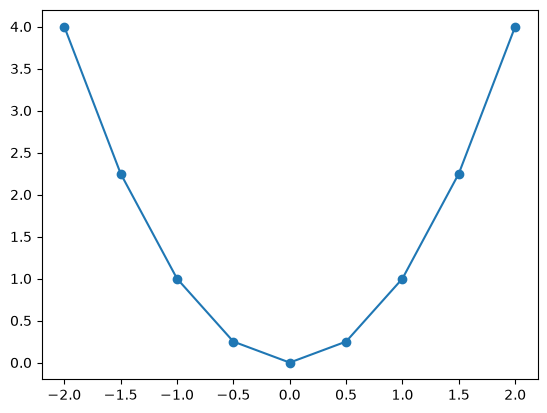

In [31]:
import matplotlib.pyplot as plt
import numpy as np

x_list = [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0]

x_np = np.array(x_list)
y_np = x_np ** 2

plt.plot(x_np, y_np, marker="o")
plt.show()

Now the same list, with one word changed: `np.array` becomes `jnp.array`.

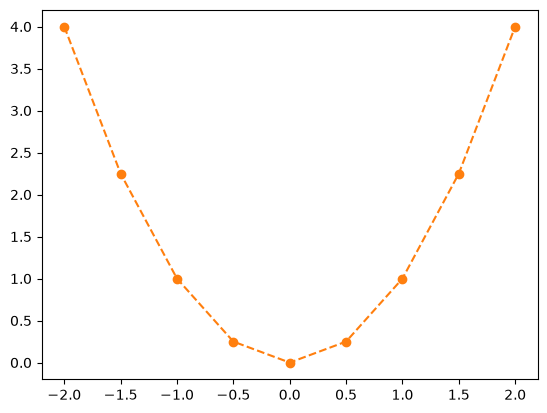

In [33]:
import jax
import jax.numpy as jnp

x = jnp.array(x_list)
y = x ** 2

plt.plot(x, y, marker="o", color="tab:orange", linestyle="--")
plt.show()

The same curve. Almost anything you can write with `numpy`, you can write with
`jax.numpy`. What JAX adds is the ability to **transform** a numerical program:
differentiate it (`jax.grad`), vectorize it (`jax.vmap`), or compile it (`jax.jit`).

## 2. Structural data as arrays

We store one structural object per row and one spatial component per column.
Below, each row is a node and the three columns are its $(x, y, z)$ coordinates.

In [34]:
xyz = jnp.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.5],
    [2.0, 0.0, 1.0],
    [3.0, 0.0, 0.5],
    [4.0, 0.0, 0.0],
])

print(xyz)
print("shape:", xyz.shape)

[[0.  0.  0. ]
 [1.  0.  0.5]
 [2.  0.  1. ]
 [3.  0.  0.5]
 [4.  0.  0. ]]
shape: (5, 3)


For a chain of nodes, the vector of each edge needs no loop:

$$
\mathbf{e}_i = \mathbf{x}_{i+1} - \mathbf{x}_i.
$$

We can gather the start and the end points of the edges using simple array indexing, and then perform the subtraction to find the edge vectors.

In [57]:
start_points = xyz[:-1]
end_points = xyz[1:]
edge_vectors = end_points - start_points

print(edge_vectors)
print("shape:", edge_vectors.shape)

[[ 1.   0.   0.5]
 [ 1.   0.   0.5]
 [ 1.   0.  -0.5]
 [ 1.   0.  -0.5]]
shape: (4, 3)


## 3. Vectorization

Now let's find out the edge lengths, $l_i = \|\mathbf{e}_i\|$. We can start by writing a Python loop, and computing lengths one edge at a time:

In [58]:
def compute_vector_length(vector):
    return jnp.sqrt(jnp.sum(vector ** 2))

def lengths_looped(vectors):
    lengths = []
    for vector in vectors:
        length = compute_vector_length(vector)
        lengths.append(length)
    return jnp.array(lengths)


print(lengths_looped(edge_vectors))

[1.118034 1.118034 1.118034 1.118034]


A second, more educated option is `jax.vmap`: write the calculation for one edge, and let JAX apply it to all of them. `jax.vmap` is a function transformation that works as a vectorizer: it takes a function written for a single vector and maps it over every _row_ of an array in one shot.

In [59]:
lengths_vectorized = jax.vmap(compute_vector_length)

print(lengths_vectorized(edge_vectors))

[1.118034 1.118034 1.118034 1.118034]


The loop is correct, so why avoid it? Because it dispatches one tiny operation per
edge. On 20,000 edges:

In [60]:
vectors = jnp.array(np.random.rand(20000, 3))

%timeit lengths_looped(vectors)
%timeit lengths_vectorized(vectors).block_until_ready()

503 ms ± 9.96 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
129 μs ± 3.29 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Thousands of times faster. Vectorize.

## 4. Automatic differentiation

Here is the first thing NumPy cannot do. If you write the parabola as a function, then  `jax.grad` returns *another function* - a function that evaluates its derivative _exactly_. JAX arrives at this function by applying reverse-mode automatic differentiation, a.k.a. _backpropagation_.

In [51]:
def squared_error(x):
    return x ** 2

derivative_fn = jax.grad(squared_error)

# One sample point on the parabola
x_i = x[2]
y_i = squared_error(x_i)
slope = derivative_fn(x_i)

print("x =", x_i, "  y =", y_i, "  slope =", slope)

x = -1.0   y = 1.0   slope = -2.0


By hand, $dy/dx = 2x$, so at $x_i = -1$ the slope should be $-2$. Let us compare JAX against that analytical reference, and plot the tangent line.

Difference JAX to analytical: 0.0


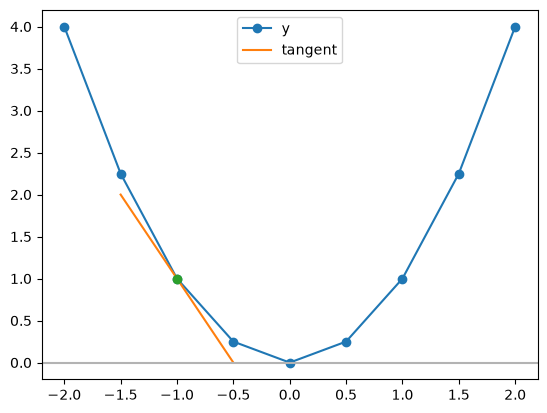

In [56]:
# Analytical slope
slope_exact = 2 * x_i
print("Difference JAX to analytical:", jnp.abs(slope - slope_exact))

# Plot the tangent: y = y_i + slope * (x - x_i)
half_width = 0.5
x_tangent = jnp.array([x_i - half_width, x_i + half_width])
y_tangent = y_i + slope * (x_tangent - x_i)

plt.plot(x, y, marker="o", label="y")
plt.plot(x_tangent, y_tangent, label="tangent")
plt.plot(x_i, y_i, marker="o")
plt.axhline(0.0, color="0.7")
plt.legend()
plt.show()

An objective, or a _loss_ function in machine learning lingo, measures the cost of some operation with a single scalar. 

To minimize the cost rapidly using gradient descent, we need, well, the gradient. Just as above, `jax.grad` provides this object, but unlike our last example, here we pass a flat array of numbers as input, and the gradient we get in return is correspondingly another vector representing the sensitivity of the loss value to changes in the input array `x`.

Note the plain Python loop and the conditional statement. JAX differentiates through both without a hitch. Start to see the coolness of automatic differentiation?

In [65]:
def loss_fn(x):
    """A loss measuring the cost of design vector x."""
    loss = 0.0
    for i, xi in enumerate(x):
        if i % 2 == 0:
            loss = loss + xi ** 2
        else:
            loss = loss + xi ** 3
    return loss


x_design = jnp.array([1.0, 2.0, 3.0, 4.0])

print("loss", loss_fn(x_design))
print("gradient", jax.grad(loss_fn)(x_design))

loss 82.0
gradient [ 2. 12.  6. 48.]


One number out, one gradient per input. That gradient says which way to move every
variable to bring the loss down, which is all gradient descent needs. Every
optimization later today runs on this.

## 5. Jacobians

`jax.grad` is compatible with functions with one scalar output. But not all functions have such a property. Most generally, functions are maps from vectors to other vectors. In form-finding, for example, one wants to compute a residual vector $\mathbf{r}$ given a structure's free 3D coordinates $\mathbf{x}$. 

The derivative of such a function is a matrix, a _Jacobian_ matrix, and for the specific mechanical quantity we just outlined, this Jacobian is the stiffness matrix $\mathbf{K}$ of a structure!

$$
\mathbf{K} = \frac{\partial \mathbf{r}}{\partial \mathbf{x}}
$$

In [73]:
def some_vector_function(v):
    """A vector-valued function of a vector."""
    a = v[0] ** 2 + v[1]
    b = v[0] - v[1]
    c = v[1] + v[2]

    return jnp.array([a, b, c])

my_vector = jnp.array([1.0, 2.0, 0.5])
jacobian_fn = jax.jacobian(some_vector_function)

print("Function output:", some_vector_function(my_vector))
print("Jacobian matrix:\n", jacobian_fn(my_vector))

Function output: [ 3.  -1.   2.5]
Jacobian matrix:
 [[ 2.  1.  0.]
 [ 1. -1.  0.]
 [ 0.  1.  1.]]


## 6. Takeaways

- **`jax.numpy` is NumPy**, with transformations on top.
- **Vectorize.** A Python loop over edges is orders of magnitude slower.
- **`jax.grad`** and **`jax.jacobian`** both hand back a *function*, not a number.
  Calling it gives a gradient when the output is a scalar, and a Jacobian matrix
  when the output is a vector. Both are exact, unlike numerical differentiation.